In [3]:
# Import some qiskit packages required for setting up our quantum circuits.
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.circuit.library import unitary_overlap
 
# Import StatevectorSampler as our sampler.
from qiskit.primitives import StatevectorSampler
 
# Step 1: Map classical inputs to a quantum problem:
 
# Start by getting some appropriate data. The data imported below consist of 128 rows or data points.
# Each row has 14 columns that correspond to data features, and a 15th column with a label (+/-1).
!wget https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv
 
# Import some required packages, and write a function to pull some training data out of the csv file you got above.
import pandas as pd
import numpy as np
 
 
def get_training_data():
    """Read the training data."""
    df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)
    training_data = df.values[:20, :]
    ind = np.argsort(training_data[:, -1])
    X_train = training_data[ind][:, :-1]
 
    return X_train
 
 
# Prepare training data
X_train = get_training_data()
 
# Empty kernel matrix
num_samples = np.shape(X_train)[0]
 
# Prepare feature map for computing overlap between two data points.
# This could be pre-built feature maps like ZZFeatureMap, or a custom quantum circuit, as shown here.
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]
fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)
 
# Pick two data points, here 14 and 19, and assign the features to the circuits as parameters.
x1 = 14
x2 = 19
unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])
 
# Create the overlap circuit
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()
overlap_circ.draw("mpl", scale=0.6, style="iqp")
 
# Step 2: Optimize problem for quantum execution
 
# Use Qiskit Runtime service to get the least busy backend for running on real quantum computers.
# from qiskit_ibm_runtime import QiskitRuntimeService
 
# service = QiskitRuntimeService(channel="ibm_quantum")
# backend = service.least_busy(
#    operational=True, simulator=False, min_num_qubits=overlap_circ.num_qubits
# )
 
# Transpile the circuits optimally for the chosen backend using a pass manager.
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
# pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
# overlap_ibm = pm.run(overlap_circ)
 
# Step 3: Execute using Qiskit Runtime Primitives
 
# Specify the number of shots to use.
num_shots = 10_000
 
## Evaluate the problem using statevector-based primitives from Qiskit
sampler = StatevectorSampler()
counts = (
    sampler.run([overlap_circ], shots=num_shots).result()[0].data.meas.get_int_counts()
)
 
# Step 4: Analyze and post-processing
 
# Find the probability of 0.
counts.get(0, 0.0) / num_shots

'wget' is not recognized as an internal or external command,
operable program or batch file.


0.6951

In [ ]:
import math
import numpy as np
from qiskit import QuantumCircuit
 
desired_state = [1 / math.sqrt(3), 0, 0, 0, 0, 1 / math.sqrt(3), 0, 1 / math.sqrt(3)]
 
qc = QuantumCircuit(3)
qc.initialize(desired_state, [0, 1, 2])
qc.decompose(reps=8).draw(output="mpl")

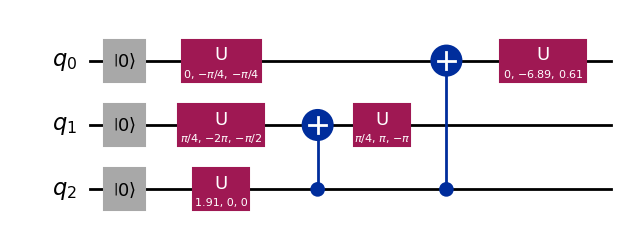

In [1]:
import math
import numpy as np
from qiskit import QuantumCircuit
 
desired_state = [1 / math.sqrt(3), 0, 0, 0, 0, 1 / math.sqrt(3), 0, 1 / math.sqrt(3)]
 
qc = QuantumCircuit(3)
qc.initialize(desired_state, [0, 1, 2])
qc.decompose(reps=8).draw(output="mpl")

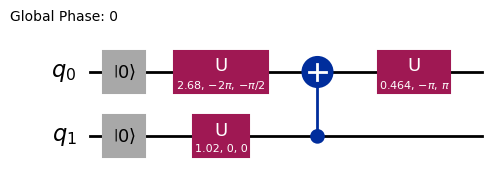

In [2]:
desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]
 
qc = QuantumCircuit(2)
qc.initialize(desired_state, [0, 1])
 
qc.decompose(reps=5).draw(output="mpl")

In [3]:
from qiskit.quantum_info import Statevector
from math import pi
 
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)
states = state1, state2

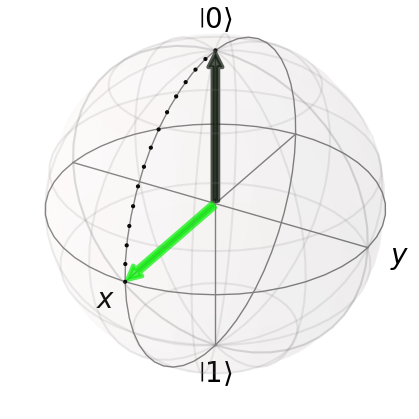

In [4]:
from qiskit.visualization.bloch import Bloch
from qiskit.visualization.state_visualization import _bloch_multivector_data
 
 
def plot_Nstates(states, axis, plot_trace_points=True):
    """This function plots N states to 1 Bloch sphere"""
    bloch_vecs = [_bloch_multivector_data(s)[0] for s in states]
 
    if axis is None:
        bloch_plot = Bloch()
    else:
        bloch_plot = Bloch(axes=axis)
 
    bloch_plot.add_vectors(bloch_vecs)
 
    if len(states) > 1:
 
        def rgba_map(x, num):
            g = (0.95 - 0.05) / (num - 1)
            i = 0.95 - g * num
            y = g * x + i
            return (0.0, y, 0.0, 0.7)
 
        num = len(states)
        bloch_plot.vector_color = [rgba_map(x, num) for x in range(1, num + 1)]
 
    bloch_plot.vector_width = 3
    bloch_plot.vector_style = "simple"
 
    if plot_trace_points:
 
        def trace_points(bloch_vec1, bloch_vec2):
            # bloch_vec = (x,y,z)
            n_points = 15
            thetas = np.arccos([bloch_vec1[2], bloch_vec2[2]])
            phis = np.arctan2(
                [bloch_vec1[1], bloch_vec2[1]], [bloch_vec1[0], bloch_vec2[0]]
            )
            if phis[1] < 0:
                phis[1] = phis[1] + 2 * pi
            angles0 = np.linspace(phis[0], phis[1], n_points)
            angles1 = np.linspace(thetas[0], thetas[1], n_points)
 
            xp = np.cos(angles0) * np.sin(angles1)
            yp = np.sin(angles0) * np.sin(angles1)
            zp = np.cos(angles1)
            pnts = [xp, yp, zp]
            bloch_plot.add_points(pnts)
            bloch_plot.point_color = "k"
            bloch_plot.point_size = [4] * len(bloch_plot.points)
            bloch_plot.point_marker = ["o"]
 
        for i in range(len(bloch_vecs) - 1):
            trace_points(bloch_vecs[i], bloch_vecs[i + 1])
 
    bloch_plot.sphere_alpha = 0.05
    bloch_plot.frame_alpha = 0.15
    bloch_plot.figsize = [4, 4]
 
    bloch_plot.render()
 
 
plot_Nstates(states, axis=None, plot_trace_points=True)

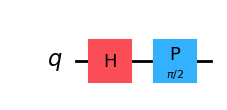

In [5]:
qc = QuantumCircuit(1)
qc.h(0)  # Hadamard gate rotates state down to Bloch equator
state1 = Statevector.from_instruction(qc)
 
qc.p(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)
 
states = state1, state2
 
qc.draw("mpl", scale=1)

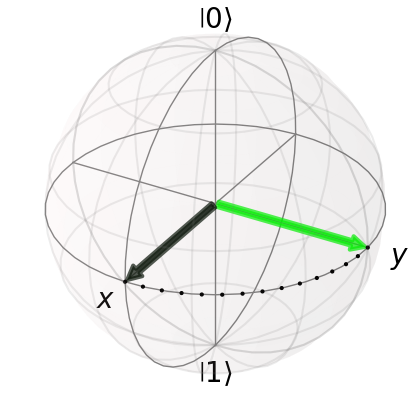

In [6]:
plot_Nstates(states, axis=None, plot_trace_points=True)

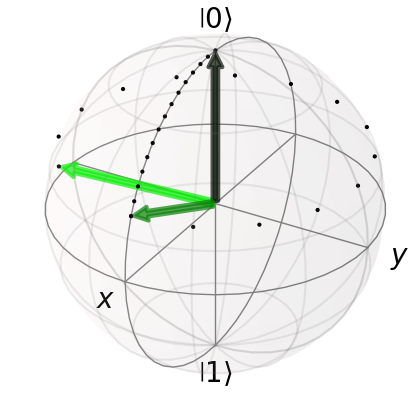

In [7]:
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)
state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)
state3 = Statevector.from_instruction(qc)
states = state1, state2, state3
 
plot_Nstates(states, axis=None, plot_trace_points=True)

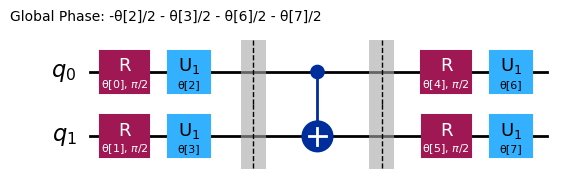

In [8]:
from qiskit.circuit.library import efficient_su2
 
circuit = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circuit.decompose().draw(output="mpl")

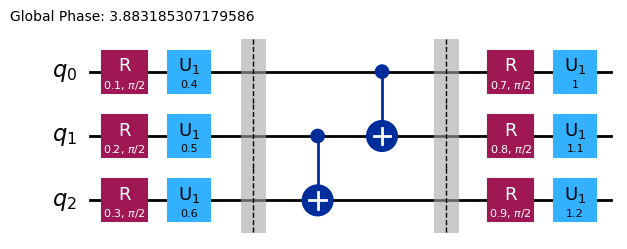

In [9]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.decompose().draw(output="mpl")

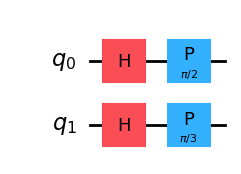

In [10]:
qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)
 
qc0.h(0)
qc0.p(pi / 2, 0)
 
qc1.h(0)
qc1.p(pi / 3, 0)
 
# Combine circuits qc0 and qc1 into 1 circuit
qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)
 
qc.draw("mpl", scale=1)

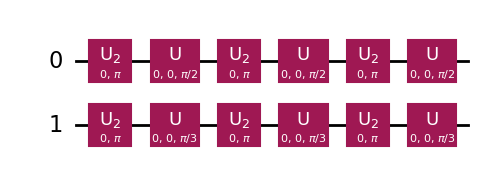

In [11]:
from qiskit.circuit.library import z_feature_map
 
zfeature_map = z_feature_map(feature_dimension=2, reps=3)
zfeature_map = zfeature_map.assign_parameters([(1 / 2) * pi / 2, (1 / 2) * pi / 3])
zfeature_map.decompose().draw("mpl")

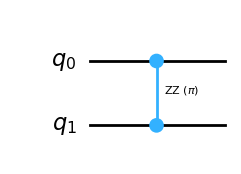

In [12]:
qc = QuantumCircuit(2)
qc.rzz(pi, 0, 1)
qc.draw("mpl", scale=1)

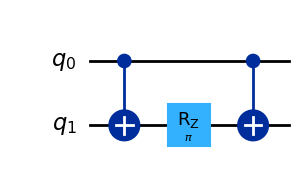

In [13]:
qc.decompose().draw("mpl", scale=1)

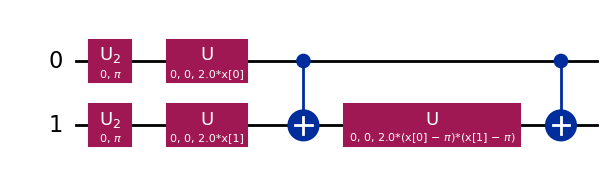

In [14]:
from qiskit.circuit.library import zz_feature_map
 
feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose(reps=1).draw("mpl", scale=1)

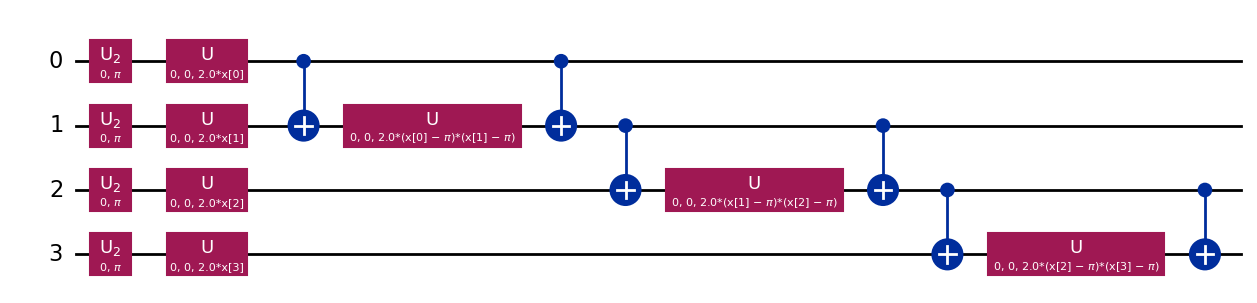

In [15]:
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose().draw("mpl", scale=1)

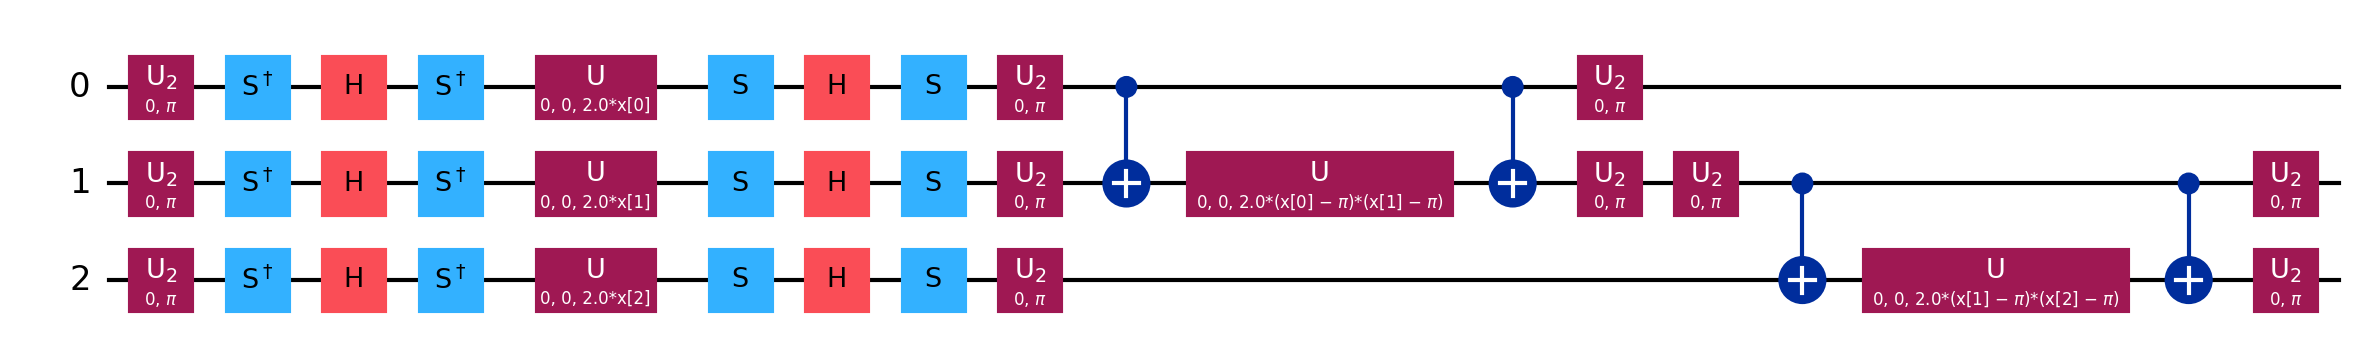

In [16]:
from qiskit.circuit.library import pauli_feature_map
 
feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)
 
pfmap.decompose().draw("mpl", scale=1.5)

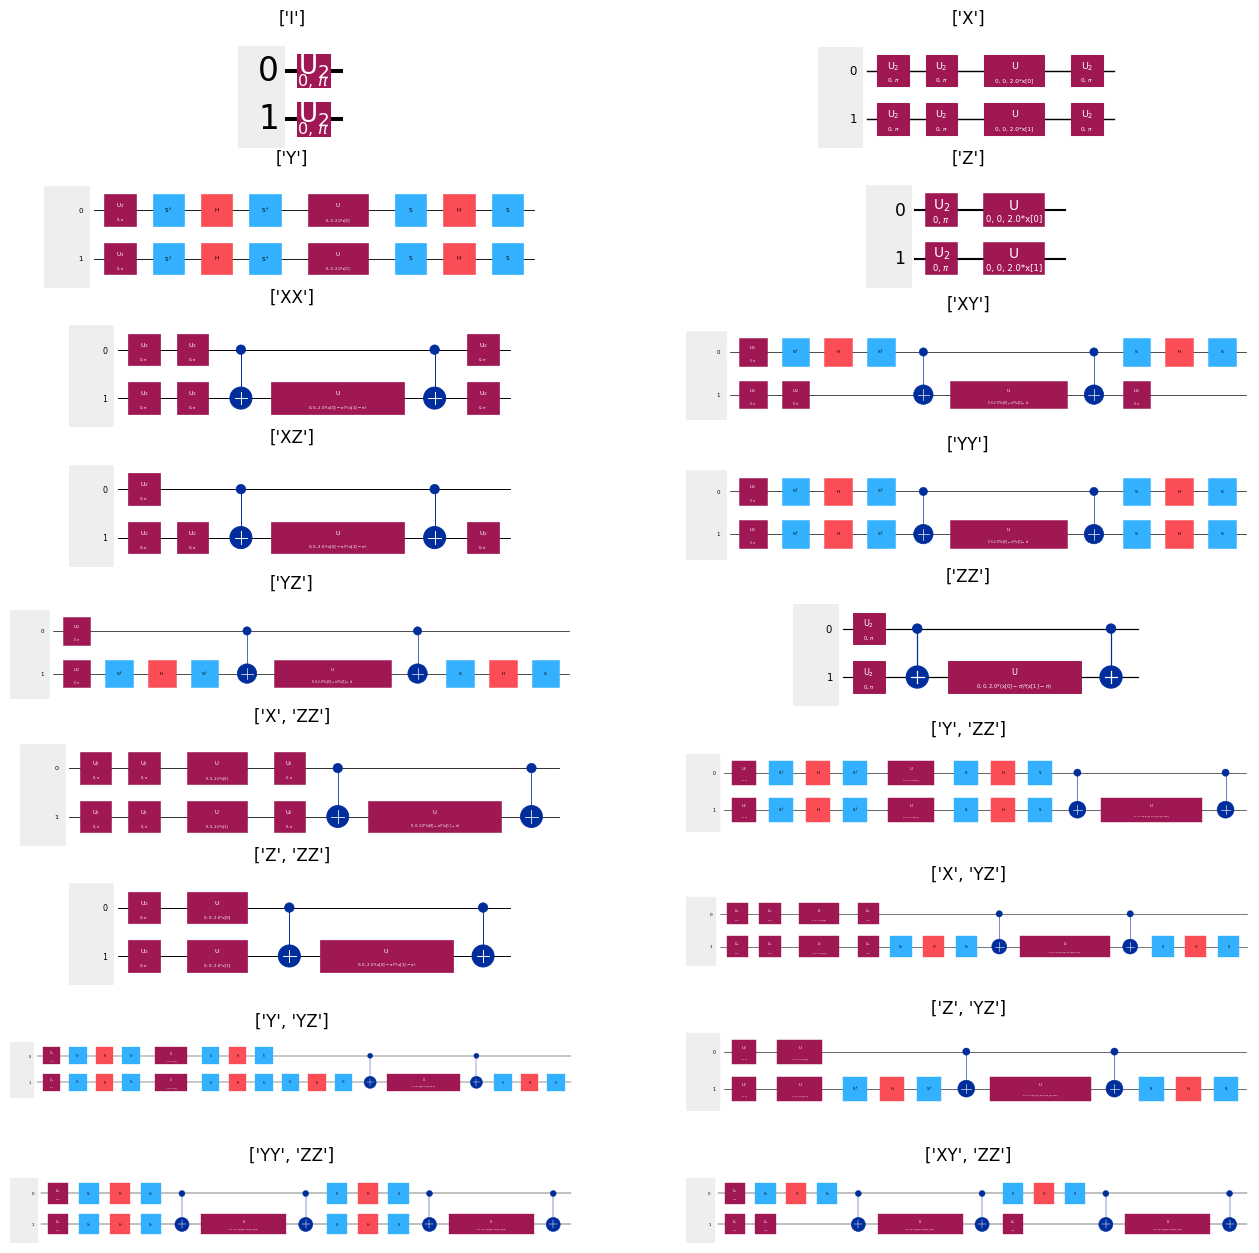

In [17]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt
 
feature_dim = 2
fig, axs = plt.subplots(9, 2)
i_plot = 0
for paulis in [
    ["I"],
    ["X"],
    ["Y"],
    ["Z"],
    ["XX"],
    ["XY"],
    ["XZ"],
    ["YY"],
    ["YZ"],
    ["ZZ"],
    ["X", "ZZ"],
    ["Y", "ZZ"],
    ["Z", "ZZ"],
    ["X", "YZ"],
    ["Y", "YZ"],
    ["Z", "YZ"],
    ["YY", "ZZ"],
    ["XY", "ZZ"],
]:
    pfmap = pauli_feature_map(feature_dimension=feature_dim, paulis=paulis, reps=1)
    circuit_drawer(
        pfmap.decompose(),
        output="mpl",
        style={"backgroundcolor": "#EEEEEE"},
        ax=axs[int((i_plot - i_plot % 2) / 2), i_plot % 2],
    )
    axs[int((i_plot - i_plot % 2) / 2), i_plot % 2].title.set_text(paulis)
    i_plot += 1
 
fig.set_figheight(16)
fig.set_figwidth(16)

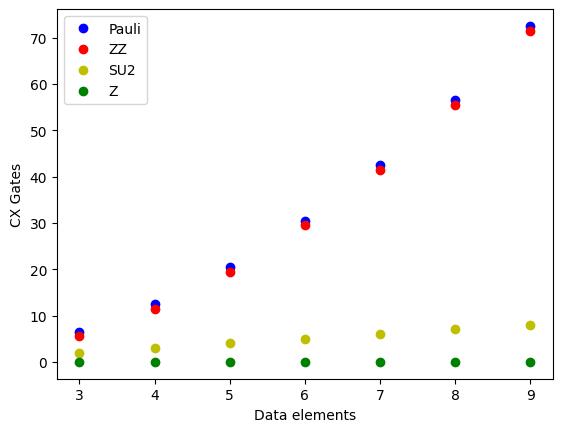

In [18]:
# Initializing parameters and empty lists for depths
x = [0.1, 0.2]
n_data = []
zz2gates = []
su22gates = []
z2gates = []
p2gates = []
 
# Generating feature maps
for n in range(3, 10):
    x.append(n / 10)
    zzcircuit = zz_feature_map(n, reps=1, insert_barriers=True)
    zcircuit = z_feature_map(n, reps=1, insert_barriers=True)
    su2circuit = efficient_su2(n, reps=1, insert_barriers=True)
    pcircuit = pauli_feature_map(n, reps=1, paulis=["XX"], insert_barriers=True)
    # Getting the cx depths
    zzcx = zzcircuit.decompose().count_ops().get("cx")
    zcx = zcircuit.decompose().count_ops().get("cx")
    su2cx = su2circuit.decompose().count_ops().get("cx")
    pcx = pcircuit.decompose().count_ops().get("cx")
 
    # Appending the cx gate counts to the lists. We shift the zz & pauli data points, because they overlap.
    n_data.append(n)
    zz2gates.append(zzcx - 0.5)
    z2gates.append(0)
    su22gates.append(su2cx)
    p2gates.append(pcx + 0.5)
 
# Plot the output
plt.plot(n_data, p2gates, "bo")
plt.plot(n_data, zz2gates, "ro")
plt.plot(n_data, su22gates, "yo")
plt.plot(n_data, z2gates, "go")
plt.ylabel("CX Gates")
plt.xlabel("Data elements")
plt.legend(["Pauli", "ZZ", "SU2", "Z"])
# plt.suptitle('zz_feature_map(n)')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
# Two mock data points, including category labels, as in training
small_data = [
    [-0.194, 0.114, -0.006, 0.301, -0.359, -0.088, -0.156, 0.342, -0.016, 0.143, 1],
    [-0.1, 0.002, 0.244, 0.127, -0.064, -0.086, 0.072, 0.043, -0.053, 0.02, -1],
]
 
# Data points with labels removed, for inner product
train_data = [small_data[0][:-1], small_data[1][:-1]]

In [2]:
# from qiskit.circuit.library import zz_feature_map
# fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)
 
from qiskit.circuit.library import z_feature_map
 
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])
 
 
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

circuit depth =  9


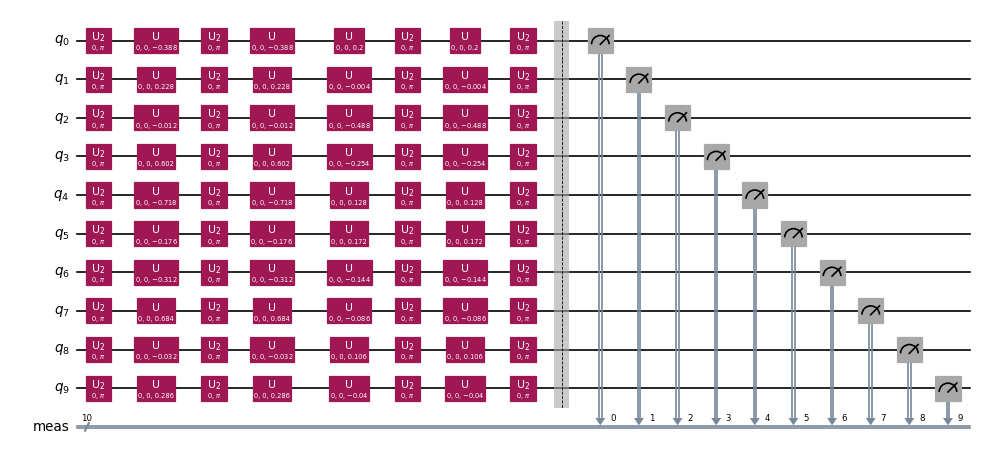

In [3]:
from qiskit.circuit.library import unitary_overlap
 
 
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()
 
print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

In [4]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
 
# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

<IBMBackend('ibm_brisbane')>


In [5]:
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

In [6]:
print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

In [ ]:
# Run this for a simulator
# from qiskit.primitives import StatevectorSampler
 
# from qiskit_ibm_runtime import Options, Session, Sampler
 
# num_shots = 10000
 
# Evaluate the problem using state vector-based primitives from Qiskit
# sampler = StatevectorSampler()
# results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
# counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
# counts = results[0].data.meas.get_int_counts()

In [7]:
# Benchmarked on ibm_kyoto, 7-11-24, took 4 sec.
 
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
 
num_shots = 10000
 
# Use sampler and get the counts
 
sampler = Sampler(mode=backend)
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [ ]:
from qiskit.visualization import plot_distribution
 
plot_distribution(counts_bit)

In [ ]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()
 
 
visualize_counts(counts, overlap_circ.num_qubits)